In [1]:
import pandas as pd
import numpy as np
import ast, re, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# 🔑 Team-wide random seed
RANDOM_STATE = 42

# Paths (relative to notebooks/ folder)
DATA_DIR = Path("../data")
FIG_DIR = Path("../outputs/figures")
FEAT_DIR = Path("../outputs/features")

print("Setup complete ✅")
print(f"DATA_DIR exists: {DATA_DIR.exists()}")
print(f"FIG_DIR exists: {FIG_DIR.exists()}")
print(f"FEAT_DIR exists: {FEAT_DIR.exists()}")

Setup complete ✅
DATA_DIR exists: True
FIG_DIR exists: True
FEAT_DIR exists: True


---

## 🔑 Team-wide conventions (please follow for comparable results)

All models in this project must use the **same train/test split** to ensure 
fair comparison across Q1/Q2 and across feature sets. The split has already 
been generated and saved — **do not call `train_test_split()` again**.

### How to load features + split (copy-paste ready)

```python
from scipy.sparse import load_npz
import numpy as np

# Features (Yuzhao's pipeline output)
X_meta_q1  = load_npz("outputs/features/X_meta_q1.npz")
X_tfidf_q1 = load_npz("outputs/features/X_tfidf_q1.npz")
y_q1       = np.load("outputs/features/y_q1.npy")

# Shared train/test indices — DO NOT call train_test_split again
train_idx = np.load("outputs/features/train_idx_q1.npy")
test_idx  = np.load("outputs/features/test_idx_q1.npy")

X_train, X_test = X_meta_q1[train_idx], X_meta_q1[test_idx]
y_train, y_test = y_q1[train_idx],      y_q1[test_idx]
```

### Project-wide constants
- `random_state=42` (project-wide; baked into saved split)
- `test_size=0.2`, `stratify=y` (baked into saved split)
- **Primary metric: macro-F1** (Q1 is 1:4 imbalanced, accuracy misleading)
- **Also report**: accuracy, precision+, recall+, confusion matrix

### Feature files (in `outputs/features/`)
- `X_meta_q1.npz / X_meta_q2.npz` — 115 features (numeric + multi-hot)
- `X_tfidf_q1.npz / X_tfidf_q2.npz` — 2000 features (TF-IDF unigrams + bigrams)
- `y_q1.npy / y_q2.npy` — labels
- `train_idx_q1.npy / test_idx_q1.npy` — shared split for Q1
- `train_idx_q2.npy / test_idx_q2.npy` — shared split for Q2
- `feature_names_meta.txt` — human-readable feature names for X_meta
- `lr_results.csv` — Logistic Regression baseline results

In [2]:
# ===== Load both datasets =====
df_q1 = pd.read_csv(DATA_DIR / "steam_q1_model_data.csv")
df_q2 = pd.read_csv(DATA_DIR / "steam_q2_model_data.csv")

# Sanity checks
print(f"Q1 shape: {df_q1.shape}  |  positive rate: {df_q1['popular'].mean():.1%}")
print(f"Q2 shape: {df_q2.shape}  |  positive rate: {df_q2['highly_positive'].mean():.1%}")

# Missing values
print(f"\n--- Missing values (Q1) ---")
print(df_q1.isnull().sum()[df_q1.isnull().sum() > 0])

# Fill missing descriptions with empty string (so text features still produce a row)
for df in [df_q1, df_q2]:
    df['short_description'] = df['short_description'].fillna('')
    df['detailed_description'] = df['detailed_description'].fillna('')
    df['name'] = df['name'].fillna('')

# Quick peek
print(f"\n--- First 3 rows of Q1 (selected columns) ---")
print(df_q1[['name', 'release_year', 'price', 'genres', 'popular']].head(3).to_string())

Q1 shape: (124146, 20)  |  positive rate: 20.6%
Q2 shape: (30621, 20)  |  positive rate: 55.1%

--- Missing values (Q1) ---
name                       1
short_description       8315
detailed_description    8428
dtype: int64

--- First 3 rows of Q1 (selected columns) ---
                                    name  release_year  price         genres  popular
0             Black Dragon Mage Playtest          2023   0.00             []        0
1  Supipara - Chapter 1 Spring Has Come!          2016   5.24  ['Adventure']        0
2      Mystery Solitaire The Black Raven          2019   4.99     ['Casual']        0


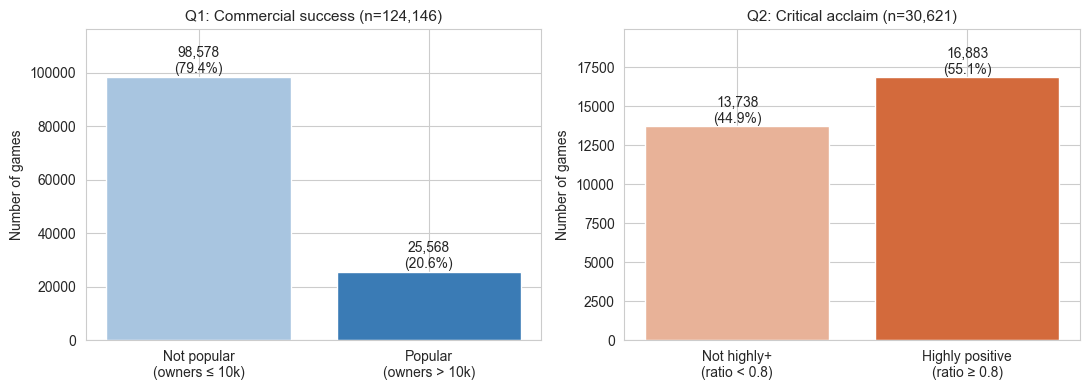


💾 Saved to ..\outputs\figures\01_target_distribution.png


In [3]:
# ===== Figure 1: Target distribution =====
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Q1: popular
q1_counts = df_q1['popular'].value_counts().sort_index()
ax1 = axes[0]
bars1 = ax1.bar(['Not popular\n(owners ≤ 10k)', 'Popular\n(owners > 10k)'], 
                q1_counts.values, color=['#a8c5e0', '#3a7bb5'])
ax1.set_title(f"Q1: Commercial success (n={len(df_q1):,})", fontsize=11)
ax1.set_ylabel("Number of games")
for bar, val in zip(bars1, q1_counts.values):
    pct = val / len(df_q1) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, val + 1500,
             f"{val:,}\n({pct:.1f}%)", ha='center', fontsize=10)
ax1.set_ylim(0, q1_counts.max() * 1.18)

# Q2: highly_positive
q2_counts = df_q2['highly_positive'].value_counts().sort_index()
ax2 = axes[1]
bars2 = ax2.bar(['Not highly+\n(ratio < 0.8)', 'Highly positive\n(ratio ≥ 0.8)'],
                q2_counts.values, color=['#e8b298', '#d36a3c'])
ax2.set_title(f"Q2: Critical acclaim (n={len(df_q2):,})", fontsize=11)
ax2.set_ylabel("Number of games")
for bar, val in zip(bars2, q2_counts.values):
    pct = val / len(df_q2) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, val + 200,
             f"{val:,}\n({pct:.1f}%)", ha='center', fontsize=10)
ax2.set_ylim(0, q2_counts.max() * 1.18)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💾 Saved to {FIG_DIR / '01_target_distribution.png'}")

## Observation 1: Target distributions

- **Q1 is highly imbalanced** (~20% positive): a trivial "always predict not popular" 
  baseline already achieves ~80% accuracy. We must report **macro-F1, precision, recall** 
  per class — accuracy alone is misleading here.
- **Q2 is roughly balanced** (~55% positive). Accuracy is more meaningful, but we still 
  report macro-F1 for consistency with Q1.
- This asymmetry is intentional in the dataset design: Q2 only includes games with ≥50 
  reviews, filtering out the long tail of obscure games that dominate Q1.

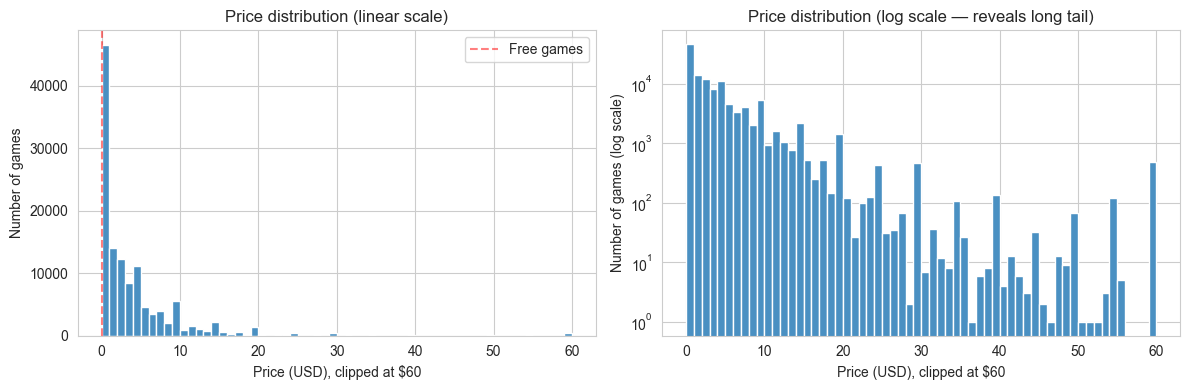

Price stats (Q1):
  Free games (price = 0):  26,412  (21.3%)
  Cheap (0 < price ≤ $5):  66,079
  Mid ($5 < price ≤ $20):  29,140
  Premium (> $20):         2,515
  Max price:               $999.98


In [4]:
# ===== Figure 2: Price distribution (log scale to see long tail) =====
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: raw histogram with linear y-axis (zoomed to <60)
ax1 = axes[0]
prices = df_q1['price'].clip(upper=60)  # clip extreme outliers (price up to $999)
ax1.hist(prices, bins=60, color='#4a90c2', edgecolor='white')
ax1.set_xlabel("Price (USD), clipped at $60")
ax1.set_ylabel("Number of games")
ax1.set_title("Price distribution (linear scale)")
ax1.axvline(0, color='red', linestyle='--', alpha=0.5, label='Free games')
ax1.legend()

# Right: log scale on y-axis to see the long tail
ax2 = axes[1]
ax2.hist(df_q1['price'].clip(upper=60), bins=60, color='#4a90c2', edgecolor='white')
ax2.set_yscale('log')
ax2.set_xlabel("Price (USD), clipped at $60")
ax2.set_ylabel("Number of games (log scale)")
ax2.set_title("Price distribution (log scale — reveals long tail)")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_price_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# Print stats
print(f"Price stats (Q1):")
print(f"  Free games (price = 0):  {(df_q1['price'] == 0).sum():,}  ({(df_q1['price']==0).mean():.1%})")
print(f"  Cheap (0 < price ≤ $5):  {((df_q1['price'] > 0) & (df_q1['price'] <= 5)).sum():,}")
print(f"  Mid ($5 < price ≤ $20):  {((df_q1['price'] > 5) & (df_q1['price'] <= 20)).sum():,}")
print(f"  Premium (> $20):         {(df_q1['price'] > 20).sum():,}")
print(f"  Max price:               ${df_q1['price'].max():.2f}")

## Observation 2: Price distribution & feature engineering decisions

- **Strong right-skew with a heavy long tail**: 53% of games priced ≤ $5, only 2% above $20. 
  Linear-scale histogram is dominated by the leftmost bin; log-scale reveals exponential 
  decay extending to ~$60+.
- **21.3% of games are free** (26,412 out of 124,146). This is a large enough share to 
  warrant a dedicated binary feature.
- **Maximum price is $999.98**, almost certainly an outlier (likely an enterprise / hardware 
  bundle). We'll either clip or accept the log transform's natural suppression.

### Feature engineering decisions from this observation
1. Apply `log1p(price)` to normalise the skewed distribution
2. Add a binary feature `is_free` = (price == 0)
3. Optionally add an ordinal `price_tier` (free / cheap / mid / premium)

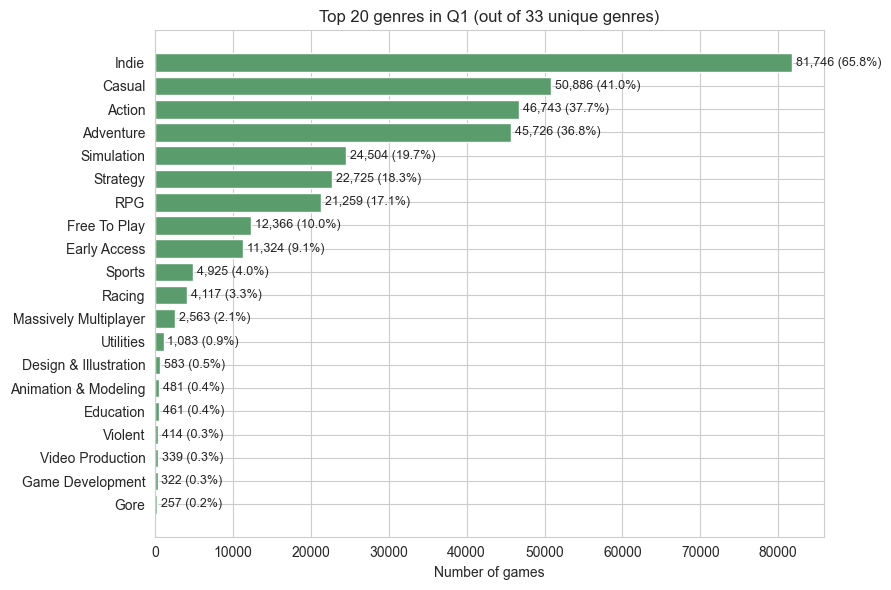


Total unique genres: 33
Games with no genre: 8,419
Mean genres per game: 2.69


In [5]:
# ===== Figure 3: Top 20 genres frequency =====
# Genres column is stored as a string like "['Action' 'Adventure']" — parse it carefully

def parse_list_field(s):
    """Parse a string like "['Action' 'Adventure']" into a Python list."""
    if pd.isna(s) or s == '[]':
        return []
    # The format uses single quotes, items separated by spaces (not commas)
    # Strip the outer brackets and split on "' '"
    s = s.strip("[]").strip()
    if not s:
        return []
    # Split items: each item is quoted with single quotes
    items = re.findall(r"'([^']*)'", s)
    return items

# Parse genres on Q1
df_q1['genres_list'] = df_q1['genres'].apply(parse_list_field)

# Count all genre occurrences
from collections import Counter
genre_counter = Counter()
for genre_list in df_q1['genres_list']:
    genre_counter.update(genre_list)

# Top 20
top_genres = genre_counter.most_common(20)
genre_names = [g[0] for g in top_genres]
genre_counts = [g[1] for g in top_genres]

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(genre_names[::-1], genre_counts[::-1], color='#5b9c6d')
ax.set_xlabel("Number of games")
ax.set_title(f"Top 20 genres in Q1 (out of {len(genre_counter)} unique genres)")
for bar, val in zip(bars, genre_counts[::-1]):
    pct = val / len(df_q1) * 100
    ax.text(val + 500, bar.get_y() + bar.get_height()/2, 
            f"{val:,} ({pct:.1f}%)", va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_top_genres.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal unique genres: {len(genre_counter)}")
print(f"Games with no genre: {(df_q1['genres_list'].apply(len) == 0).sum():,}")
print(f"Mean genres per game: {df_q1['genres_list'].apply(len).mean():.2f}")

## Observation 3: Genre distribution

- **33 unique genres** — relatively small label space, well-suited for multi-hot encoding 
  (33 binary columns, manageable dimensionality).
- **Indie dominates at 65.8%** (81,746 games). This high prevalence raises a concern: the 
  Indie label may be too common to be discriminative for popularity prediction. We expect 
  the model to find more signal in rarer, more specific genres.
- **Top 4 genres are very broad** (Indie, Casual, Action, Adventure — all > 36%), while 
  the long tail (Sports, Racing, Utilities, etc.) is sparse but specific.
- **Mean 2.69 genres per game**: most games have multiple genres → multi-hot is the right 
  encoding (not one-hot).
- **6.8% of games have no genre** (8,419 games). After multi-hot encoding these will appear 
  as all-zero rows in the genre block, which is acceptable.

### Decision
- Apply multi-hot encoding over all 33 genres
- Same approach will be applied to `categories` field

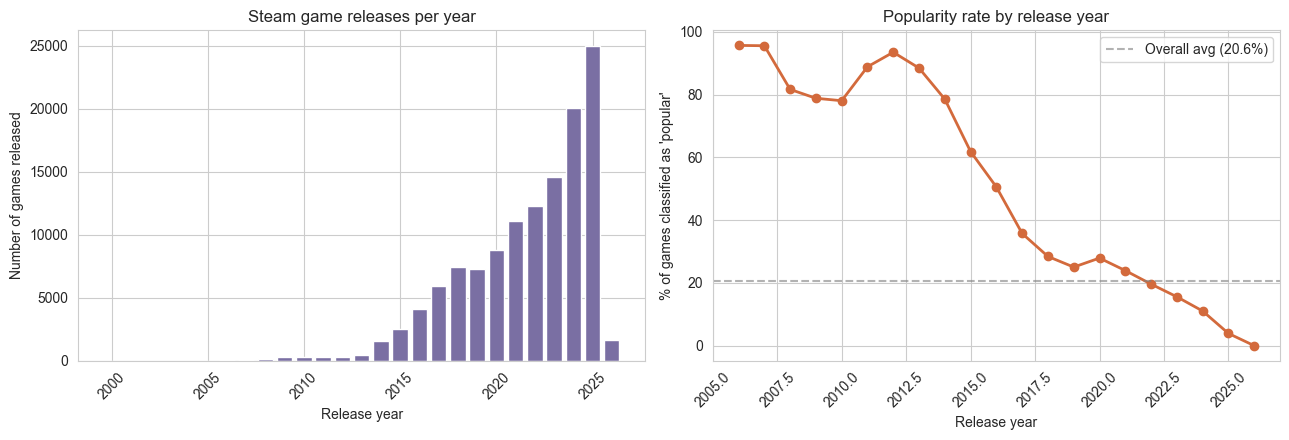

Earliest year: 1997
Latest year:   2026
Games released 2020+:  93,373
Games released 2015–19: 27,280


In [6]:
# ===== Figure 4: Release year distribution + target rate by year =====
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: number of releases per year
year_counts = df_q1['release_year'].value_counts().sort_index()
year_counts = year_counts[year_counts.index >= 2000]  # filter out very old/invalid years

ax1 = axes[0]
ax1.bar(year_counts.index, year_counts.values, color='#7a6fa3', edgecolor='white')
ax1.set_xlabel("Release year")
ax1.set_ylabel("Number of games released")
ax1.set_title("Steam game releases per year")
ax1.tick_params(axis='x', rotation=45)

# Right: positive rate (popularity) per year — does the rate change over time?
pop_rate_by_year = df_q1[df_q1['release_year'] >= 2000].groupby('release_year')['popular'].agg(['mean', 'count'])
pop_rate_by_year = pop_rate_by_year[pop_rate_by_year['count'] >= 50]  # only years with enough samples

ax2 = axes[1]
ax2.plot(pop_rate_by_year.index, pop_rate_by_year['mean'] * 100, 
         marker='o', linewidth=2, color='#d36a3c')
ax2.set_xlabel("Release year")
ax2.set_ylabel("% of games classified as 'popular'")
ax2.set_title("Popularity rate by release year")
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(df_q1['popular'].mean() * 100, color='gray', linestyle='--', 
            alpha=0.6, label=f"Overall avg ({df_q1['popular'].mean()*100:.1f}%)")
ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "04_release_year.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Earliest year: {df_q1['release_year'].min()}")
print(f"Latest year:   {df_q1['release_year'].max()}")
print(f"Games released 2020+:  {(df_q1['release_year'] >= 2020).sum():,}")
print(f"Games released 2015–19: {((df_q1['release_year'] >= 2015) & (df_q1['release_year'] < 2020)).sum():,}")

## Observation 4: Temporal bias — a major finding 🚨

### What we see
- Steam game releases have **exploded since 2015**, with 2025–2026 being the largest cohort 
  (~25,000 games/year). Pre-2010 the platform was very small.
- **Popularity rate decays sharply with release year**: 2005 games are ~95% "popular", 
  2020 games are ~30%, 2025 games are nearly 0%.

### Why this happens
`popular = (top 25% by estimated ownership, threshold > 10,000)` is a *cumulative* metric. 
A 2005 game has had 20 years to accumulate enough owners; a 2025 game has had weeks. 
Combined with **survivorship bias** (old games that still appear in the dataset are typically those that mattered), 
this creates a strong negative correlation between `release_year` and `popular`.

### Implications for modelling
- Using `release_year` directly as a feature lets the model "cheat" by exploiting game age 
  rather than learning meaningful patterns about game *quality*.
- Reported accuracy could look high simply because the model predicts "popular" for old 
  games and "not popular" for new games.

### Decision
- Convert `release_year` → `game_age = 2026 - release_year` (more interpretable)
- **Discuss this bias prominently** in the report's Discussion section
- Flag this as a candidate angle for future work (e.g., temporal splits where train uses 
  pre-2020 games and test uses post-2020 — this directly probes generalisation under 
  distribution shift)

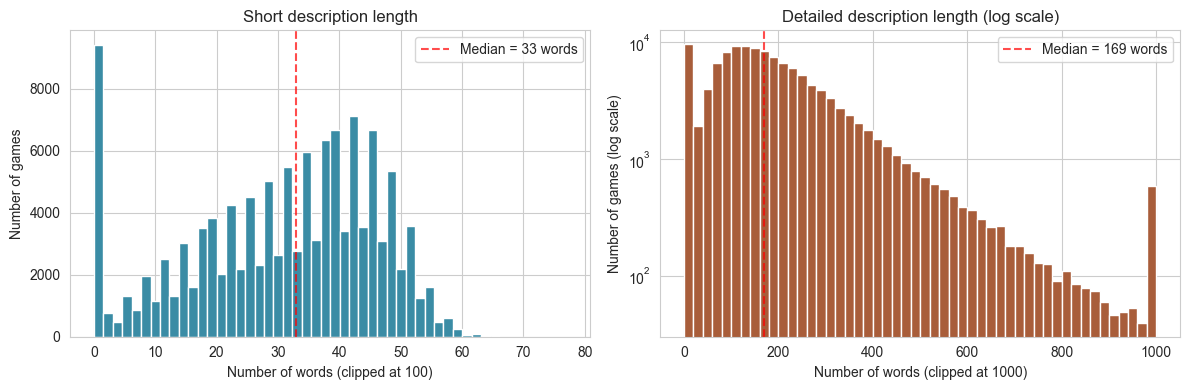

Short description:
  Empty (0 words):   8,315  (6.7%)
  Median words:      33
  Mean words:        30.7

Detailed description:
  Empty (0 words):   8,428
  Median words:      169
  Mean words:        203.4
  Max words:         11,530


In [7]:
# ===== Figure 5: Description length distribution (for text feature engineering) =====
# Word count of short + detailed descriptions
df_q1['short_desc_words'] = df_q1['short_description'].str.split().str.len().fillna(0)
df_q1['detail_desc_words'] = df_q1['detailed_description'].str.split().str.len().fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Short description length
ax1 = axes[0]
short_clip = df_q1['short_desc_words'].clip(upper=100)
ax1.hist(short_clip, bins=50, color='#3a8ca5', edgecolor='white')
ax1.set_xlabel("Number of words (clipped at 100)")
ax1.set_ylabel("Number of games")
ax1.set_title("Short description length")
ax1.axvline(short_clip.median(), color='red', linestyle='--', alpha=0.7,
            label=f'Median = {int(short_clip.median())} words')
ax1.legend()

# Detailed description length (log y-axis because of long tail)
ax2 = axes[1]
detail_clip = df_q1['detail_desc_words'].clip(upper=1000)
ax2.hist(detail_clip, bins=50, color='#a85d3a', edgecolor='white')
ax2.set_xlabel("Number of words (clipped at 1000)")
ax2.set_ylabel("Number of games (log scale)")
ax2.set_yscale('log')
ax2.set_title("Detailed description length (log scale)")
ax2.axvline(detail_clip.median(), color='red', linestyle='--', alpha=0.7,
            label=f'Median = {int(detail_clip.median())} words')
ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "05_description_length.png", dpi=150, bbox_inches='tight')
plt.show()

# Stats
print(f"Short description:")
print(f"  Empty (0 words):   {(df_q1['short_desc_words'] == 0).sum():,}  ({(df_q1['short_desc_words']==0).mean():.1%})")
print(f"  Median words:      {df_q1['short_desc_words'].median():.0f}")
print(f"  Mean words:        {df_q1['short_desc_words'].mean():.1f}")

print(f"\nDetailed description:")
print(f"  Empty (0 words):   {(df_q1['detail_desc_words'] == 0).sum():,}")
print(f"  Median words:      {df_q1['detail_desc_words'].median():.0f}")
print(f"  Mean words:        {df_q1['detail_desc_words'].mean():.1f}")
print(f"  Max words:         {df_q1['detail_desc_words'].max():,}")

## Observation 5: Description length & text feature engineering plan

- **Short description**: median 33 words, mean 30.7. Compact and informative — ideal for 
  TF-IDF. 6.7% are empty.
- **Detailed description**: median 169 words, mean 203, but ranges up to **11,530 words**. 
  Steam store descriptions contain HTML markup (`<br>`, `<a>`, etc.) that must be stripped.
- Combined missing rate (~7%) aligns with the missing-genre rate seen earlier — same 
  cohort of "barely-populated" listings.

### Decisions for text features
- Strip HTML tags from detailed descriptions before tokenisation
- Combine `short_description + detailed_description` into one text field per game
- Start TF-IDF with `max_features=500` (will inspect and grow if useful)
- Add derived numeric feature: `desc_word_count` (description length as a quality proxy)

---

## EDA Summary
5 figures saved to `outputs/figures/`. Key findings:
1. Q1 is imbalanced (1:4), Q2 is balanced
2. Strong long-tail in pricing; 21% free games
3. 33 unique genres, Indie dominates (65.8%)
4. **Temporal bias**: popularity rate drops from 95% (old) to ~0% (new)
5. Text fields are rich (median 33 + 169 words)

In [ ]:
# ===== Parse all list-like fields =====
# Steam CSV stores these as strings like "['Action' 'Adventure']" — need parsing

# Note: 'tags' is intentionally excluded — inspection of the upstream dataset
# shows tags=[] for nearly all games (sparsity makes the field unusable as a feature).
# Confirmed with Ruidong's dataclean output. 
LIST_FIELDS = ['genres', 'categories', 'developers', 'publishers', 
               'supported_languages', 'full_audio_languages']

def parse_list_field(s):
    """Parse a string like "['Action' 'Adventure']" into a Python list."""
    if pd.isna(s) or s == '[]' or s == '':
        return []
    s = s.strip("[]").strip()
    if not s:
        return []
    items = re.findall(r"'([^']*)'", s)
    return items

# Apply to both datasets, store as new columns with _list suffix
for df in [df_q1, df_q2]:
    for field in LIST_FIELDS:
        df[field + '_list'] = df[field].apply(parse_list_field)

# Verify
print("=== Sample parsed lists (Q1, first game with content) ===")
sample = df_q1[df_q1['genres_list'].apply(len) > 0].iloc[0]
print(f"  Name: {sample['name']}")
for field in LIST_FIELDS:
    print(f"  {field}: {sample[field + '_list']}")

# Coverage check
print(f"\n=== Coverage (% non-empty) — Q1 ===")
for field in LIST_FIELDS:
    pct = (df_q1[field + '_list'].apply(len) > 0).mean()
    print(f"  {field}: {pct:.1%}")

=== Sample parsed lists (Q1, first game with content) ===
  Name: Supipara - Chapter 1 Spring Has Come!
  genres: ['Adventure']
  categories: ['Single-player', 'Steam Trading Cards', 'Steam Cloud', 'Family Sharing']
  developers: ['minori']
  publishers: ['MangaGamer']
  supported_languages: ['English']
  full_audio_languages: []

=== Coverage (% non-empty) — Q1 ===
  genres: 93.2%
  categories: 92.8%
  developers: 92.6%
  publishers: 92.3%
  supported_languages: 93.2%
  full_audio_languages: 40.7%


In [9]:
# ===== Step 16 (REVISED): Multi-hot for low-cardinality fields ONLY =====
# Languages have 100+ unique values — replaced with derived numeric features instead.
from sklearn.preprocessing import MultiLabelBinarizer

# Truly low-cardinality fields: full multi-hot
LOW_CARD_FIELDS = ['genres', 'categories']

binarizers = {}
multihot_q1 = {}
multihot_q2 = {}

for field in LOW_CARD_FIELDS:
    mlb = MultiLabelBinarizer()
    multihot_q1[field] = mlb.fit_transform(df_q1[field + '_list'])
    multihot_q2[field] = mlb.transform(df_q2[field + '_list'])
    binarizers[field] = mlb
    print(f"  {field}: {multihot_q1[field].shape[1]} unique values "
          f"→ Q1 {multihot_q1[field].shape}, Q2 {multihot_q2[field].shape}")

# ===== Language fields → derived numeric features (much cleaner than 250+ multi-hot cols) =====
# Identify top-3 most common languages for explicit "has_X" flags
from collections import Counter
all_langs = Counter()
for lang_list in df_q1['supported_languages_list']:
    all_langs.update(lang_list)
print(f"\n=== Top 10 most common supported languages ===")
for lang, count in all_langs.most_common(10):
    pct = count / len(df_q1) * 100
    print(f"  {lang:25s}: {count:,} ({pct:.1f}%)")

# Build derived features for both datasets
for df in [df_q1, df_q2]:
    df['n_supported_languages'] = df['supported_languages_list'].apply(len)
    df['n_audio_languages']     = df['full_audio_languages_list'].apply(len)
    df['has_english']           = df['supported_languages_list'].apply(
        lambda L: any('English' in str(x) for x in L)).astype(int)
    df['has_chinese']           = df['supported_languages_list'].apply(
        lambda L: any('Chinese' in str(x) for x in L)).astype(int)
    df['has_japanese']          = df['supported_languages_list'].apply(
        lambda L: any('Japanese' in str(x) for x in L)).astype(int)
    df['has_full_audio']        = (df['n_audio_languages'] > 0).astype(int)

LANG_DERIVED = ['n_supported_languages', 'n_audio_languages',
                'has_english', 'has_chinese', 'has_japanese', 'has_full_audio']

print(f"\n=== Derived language features (Q1) ===")
print(df_q1[LANG_DERIVED].describe().round(2))

# Sanity check
print(f"\n=== Top 10 genres (sanity check, should match Cell 7's chart) ===")
genre_counts_check = multihot_q1['genres'].sum(axis=0)
genre_names = binarizers['genres'].classes_
top10_idx = np.argsort(-genre_counts_check)[:10]
for i in top10_idx:
    print(f"  {genre_names[i]:20s}: {genre_counts_check[i]:,}")

  genres: 33 unique values → Q1 (124146, 33), Q2 (30621, 33)
  categories: 58 unique values → Q1 (124146, 58), Q2 (30621, 58)

=== Top 10 most common supported languages ===
  English                  : 110,592 (89.1%)
  Simplified Chinese       : 34,185 (27.5%)
  German                   : 30,124 (24.3%)
  French                   : 29,935 (24.1%)
  Japanese                 : 29,661 (23.9%)
  Spanish - Spain          : 28,013 (22.6%)
  Russian                  : 27,962 (22.5%)
  Italian                  : 20,830 (16.8%)
  Korean                   : 19,840 (16.0%)
  Portuguese - Brazil      : 18,057 (14.5%)

=== Derived language features (Q1) ===
       n_supported_languages  n_audio_languages  has_english  has_chinese  \
count              124146.00          124146.00    124146.00    124146.00   
mean                    5.23               1.84         0.89         0.29   
std                    13.54              10.01         0.31         0.45   
min                     0.00         

In [10]:
# ===== Step 17: developers / publishers - frequency encoding + top-N flags =====
# These fields have tens of thousands of unique values, so multi-hot is infeasible.
# Strategy:
#   1. Frequency encoding: replace each developer with how many games they made (a "studio size" signal)
#   2. Top-N indicator: flag whether the game is from a "well-known" studio (top 50 by game count)

HIGH_CARD_FIELDS = ['developers', 'publishers']

# Build frequency tables from Q1
dev_counts = Counter()
for dev_list in df_q1['developers_list']:
    dev_counts.update(dev_list)

pub_counts = Counter()
for pub_list in df_q1['publishers_list']:
    pub_counts.update(pub_list)

print(f"Unique developers: {len(dev_counts):,}")
print(f"Unique publishers: {len(pub_counts):,}")

# Show top 10 (sanity check + interesting finding)
print(f"\n=== Top 10 most prolific developers ===")
for name, count in dev_counts.most_common(10):
    print(f"  {name:35s}: {count:,} games")

print(f"\n=== Top 10 most prolific publishers ===")
for name, count in pub_counts.most_common(10):
    print(f"  {name:35s}: {count:,} games")

# Top-50 sets for the "is well-known" flag
TOP50_DEVS = set([d for d, _ in dev_counts.most_common(50)])
TOP50_PUBS = set([p for p, _ in pub_counts.most_common(50)])

# Build derived features for both datasets
for df in [df_q1, df_q2]:
    # Frequency encoding: max count across all developers/publishers for a game
    # (if a game has multiple, use the max - representing the "biggest" partner involved)
    df['max_dev_games'] = df['developers_list'].apply(
        lambda L: max([dev_counts.get(d, 0) for d in L], default=0))
    df['max_pub_games'] = df['publishers_list'].apply(
        lambda L: max([pub_counts.get(p, 0) for p in L], default=0))
    df['is_top50_dev']  = df['developers_list'].apply(
        lambda L: int(any(d in TOP50_DEVS for d in L)))
    df['is_top50_pub']  = df['publishers_list'].apply(
        lambda L: int(any(p in TOP50_PUBS for p in L)))
    df['n_developers']  = df['developers_list'].apply(len)
    df['n_publishers']  = df['publishers_list'].apply(len)

DEVPUB_DERIVED = ['max_dev_games', 'max_pub_games',
                  'is_top50_dev', 'is_top50_pub',
                  'n_developers', 'n_publishers']

print(f"\n=== Derived dev/pub features (Q1) ===")
print(df_q1[DEVPUB_DERIVED].describe().round(2))

Unique developers: 75,976
Unique publishers: 63,203

=== Top 10 most prolific developers ===
  EroticGamesClub                    : 232 games
  Choice of Games                    : 179 games
  Boogygames Studios                 : 157 games
  Laush Dmitriy Sergeevich           : 152 games
  Bully Revenge Studios              : 146 games
  Creobit                            : 145 games
  Gamesforgames                      : 133 games
  Tero Lunkka                        : 124 games
  Cyber Keks                         : 121 games
  KOEI TECMO GAMES CO., LTD.         : 119 games

=== Top 10 most prolific publishers ===
  BFG Entertainment                  : 554 games
  8floor                             : 268 games
  EroticGamesClub                    : 232 games
  PlayWay S.A.                       : 220 games
  Strategy First                     : 206 games
  Kagura Games                       : 197 games
  Conglomerate 5                     : 197 games
  Hede                           

## Observation 6: Developer/Publisher frequency — counterintuitive finding

Encoding developer "prolificacy" via `max_dev_games` revealed an important caveat:
- **Top-prolific developers are dominated by mass-production studios** (e.g., 
  EroticGamesClub with 232 games, Boogygames Studios with 157 games), not traditional 
  AAA studios. Major studios like KOEI TECMO appear far lower in the ranking despite 
  much greater per-game success.
- This means **`max_dev_games` may correlate *negatively* with popularity at the high 
  end** — the opposite of our initial intuition.

### Implication
- Keep the feature, but interpret carefully in Discussion: it captures **output volume**, 
  not **per-game quality**.
- The `is_top50_dev` flag may have similar caveats.
- We may consider adding a `developer_avg_quality` feature in future work (mean popularity 
  rate across the developer's portfolio) — but this is left as a limitation for now.

In [11]:
# ===== Step 19: Numerical features + derived features =====
# Combines: log-transformed numerics, booleans, and derived features designed earlier.

CURRENT_YEAR = 2026  # for game_age

for df in [df_q1, df_q2]:
    # ----- Numerical transformations -----
    df['log_price']        = np.log1p(df['price'])          # log(1+price) handles 0 + long tail
    df['log_achievements'] = np.log1p(df['achievements'])   # achievements range 0–9821
    df['log_dlc_count']    = np.log1p(df['dlc_count'])      # most games have 0 DLC
    
    # ----- Derived from existing fields -----
    df['game_age']         = (CURRENT_YEAR - df['release_year']).clip(lower=0)
    df['is_free']          = (df['price'] == 0).astype(int)
    df['has_dlc']          = (df['dlc_count'] > 0).astype(int)
    df['n_platforms']      = df[['windows', 'mac', 'linux']].sum(axis=1)
    df['has_achievements'] = (df['achievements'] > 0).astype(int)
    
    # ----- Description-length features (already computed for Q1 in EDA, recompute for Q2) -----
    df['short_desc_words']  = df['short_description'].str.split().str.len().fillna(0).astype(int)
    df['detail_desc_words'] = df['detailed_description'].str.split().str.len().fillna(0).astype(int)
    df['log_detail_words']  = np.log1p(df['detail_desc_words'])
    df['has_description']   = (df['short_desc_words'] > 0).astype(int)

# Define the final numerical feature list
NUMERIC_FEATURES = [
    'log_price', 'log_achievements', 'log_dlc_count',
    'game_age', 'is_free', 'has_dlc',
    'n_platforms', 'has_achievements',
    'short_desc_words', 'log_detail_words', 'has_description',
    'required_age',
    # Language-derived from Cell 16
    'n_supported_languages', 'n_audio_languages',
    'has_english', 'has_chinese', 'has_japanese', 'has_full_audio',
    # Dev/pub-derived from Cell 17
    'max_dev_games', 'max_pub_games',
    'is_top50_dev', 'is_top50_pub',
    'n_developers', 'n_publishers',
]

# Apply log to the two frequency-encoded fields (since they range 1 → 200+)
for df in [df_q1, df_q2]:
    df['max_dev_games']  = np.log1p(df['max_dev_games'])
    df['max_pub_games']  = np.log1p(df['max_pub_games'])

print(f"Total numerical features: {len(NUMERIC_FEATURES)}")
print(f"\n=== Sample values (Q1, first 3 rows) ===")
print(df_q1[NUMERIC_FEATURES].head(3).round(2).to_string())

print(f"\n=== Stats (Q1) ===")
print(df_q1[NUMERIC_FEATURES].describe().round(2).T[['mean', 'std', 'min', 'max']])

Total numerical features: 24

=== Sample values (Q1, first 3 rows) ===
   log_price  log_achievements  log_dlc_count  game_age  is_free  has_dlc  n_platforms  has_achievements  short_desc_words  log_detail_words  has_description  required_age  n_supported_languages  n_audio_languages  has_english  has_chinese  has_japanese  has_full_audio  max_dev_games  max_pub_games  is_top50_dev  is_top50_pub  n_developers  n_publishers
0       0.00               0.0            0.0         3        1        0            1                 0                 0              0.00                0             0                      0                  0            0            0             0               0           0.00           0.00             0             0             0             0
1       1.83               0.0            0.0        10        0        0            1                 0                47              5.56                1             0                      1                  0    

In [12]:
# ===== Step 20: Build final X_meta matrix and save =====
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler

# Apply log to high-range count features (sanity)
for df in [df_q1, df_q2]:
    df['log_n_languages'] = np.log1p(df['n_supported_languages'])
    df['log_n_audio']     = np.log1p(df['n_audio_languages'])
    df['log_n_devs']      = np.log1p(df['n_developers'])
    df['log_n_pubs']      = np.log1p(df['n_publishers'])

# Final feature list — replace raw counts with log versions where we just made them
NUMERIC_FEATURES_FINAL = [
    # Price / content
    'log_price', 'log_achievements', 'log_dlc_count', 'is_free', 'has_dlc', 'has_achievements',
    # Game metadata
    'game_age', 'required_age', 'n_platforms',
    # Description
    'short_desc_words', 'log_detail_words', 'has_description',
    # Language (log + binary flags)
    'log_n_languages', 'log_n_audio', 
    'has_english', 'has_chinese', 'has_japanese', 'has_full_audio',
    # Developer / publisher
    'max_dev_games', 'max_pub_games',     # already log-transformed in Cell 19
    'is_top50_dev', 'is_top50_pub',
    'log_n_devs', 'log_n_pubs',
]
print(f"Final numeric features: {len(NUMERIC_FEATURES_FINAL)}")

# Standardise numeric features (fit on Q1, transform both — keeps train/test consistent)
scaler = StandardScaler()
X_num_q1 = scaler.fit_transform(df_q1[NUMERIC_FEATURES_FINAL].astype(float))
X_num_q2 = scaler.transform(df_q2[NUMERIC_FEATURES_FINAL].astype(float))
print(f"Numeric block:    Q1 {X_num_q1.shape},  Q2 {X_num_q2.shape}")

# Multi-hot blocks (already created in Cell 16)
X_genres_q1 = multihot_q1['genres']
X_genres_q2 = multihot_q2['genres']
X_cats_q1   = multihot_q1['categories']
X_cats_q2   = multihot_q2['categories']
print(f"Genres block:     Q1 {X_genres_q1.shape},  Q2 {X_genres_q2.shape}")
print(f"Categories block: Q1 {X_cats_q1.shape},  Q2 {X_cats_q2.shape}")

# Concatenate all blocks horizontally → final X_meta
# Use sparse matrices to save memory (multi-hot is sparse)
X_meta_q1 = hstack([csr_matrix(X_num_q1), csr_matrix(X_genres_q1), csr_matrix(X_cats_q1)]).tocsr()
X_meta_q2 = hstack([csr_matrix(X_num_q2), csr_matrix(X_genres_q2), csr_matrix(X_cats_q2)]).tocsr()

print(f"\n=== FINAL X_meta ===")
print(f"  Q1: {X_meta_q1.shape}  (popular labels: {df_q1['popular'].sum():,} positive)")
print(f"  Q2: {X_meta_q2.shape}  (highly_positive labels: {df_q2['highly_positive'].sum():,} positive)")

# Save feature names for documentation
FEATURE_NAMES = (NUMERIC_FEATURES_FINAL 
                 + [f'genre_{g}'    for g in binarizers['genres'].classes_]
                 + [f'category_{c}' for c in binarizers['categories'].classes_])
print(f"\n  Total feature names: {len(FEATURE_NAMES)}")
print(f"  First 5: {FEATURE_NAMES[:5]}")
print(f"  Last 5:  {FEATURE_NAMES[-5:]}")

# Save matrices + labels + feature names
from scipy.sparse import save_npz

save_npz(FEAT_DIR / "X_meta_q1.npz", X_meta_q1)
save_npz(FEAT_DIR / "X_meta_q2.npz", X_meta_q2)

# Labels and appIDs (so team members can join back)
np.save(FEAT_DIR / "y_q1.npy",  df_q1['popular'].values)
np.save(FEAT_DIR / "y_q2.npy",  df_q2['highly_positive'].values)
np.save(FEAT_DIR / "appID_q1.npy", df_q1['appID'].values)
np.save(FEAT_DIR / "appID_q2.npy", df_q2['appID'].values)

# Feature names (txt for human-readability)
with open(FEAT_DIR / "feature_names_meta.txt", "w", encoding='utf-8') as f:
    for name in FEATURE_NAMES:
        f.write(name + "\n")

print(f"\n💾 Saved to {FEAT_DIR}/")
print(f"   - X_meta_q1.npz, X_meta_q2.npz")
print(f"   - y_q1.npy, y_q2.npy")
print(f"   - appID_q1.npy, appID_q2.npy")
print(f"   - feature_names_meta.txt")

# ===== Save shared train/test split indices (team-wide convention) =====
# Every model in this project MUST load these indices instead of calling
# train_test_split() again — otherwise cross-model comparisons aren't strict.
from sklearn.model_selection import train_test_split

# Q1 split
idx_q1 = np.arange(X_meta_q1.shape[0])
train_idx_q1, test_idx_q1 = train_test_split(
    idx_q1, test_size=0.2, random_state=RANDOM_STATE,
    stratify=df_q1['popular'].values
)
np.save(FEAT_DIR / "train_idx_q1.npy", train_idx_q1)
np.save(FEAT_DIR / "test_idx_q1.npy",  test_idx_q1)

# Q2 split
idx_q2 = np.arange(X_meta_q2.shape[0])
train_idx_q2, test_idx_q2 = train_test_split(
    idx_q2, test_size=0.2, random_state=RANDOM_STATE,
    stratify=df_q2['highly_positive'].values
)
np.save(FEAT_DIR / "train_idx_q2.npy", train_idx_q2)
np.save(FEAT_DIR / "test_idx_q2.npy",  test_idx_q2)

print(f"   - train_idx_q1.npy / test_idx_q1.npy ({len(train_idx_q1):,} / {len(test_idx_q1):,})")
print(f"   - train_idx_q2.npy / test_idx_q2.npy ({len(train_idx_q2):,} / {len(test_idx_q2):,})")
print(f"\n🔑 Team note: all models must load these indices, not call train_test_split again.")

Final numeric features: 24
Numeric block:    Q1 (124146, 24),  Q2 (30621, 24)
Genres block:     Q1 (124146, 33),  Q2 (30621, 33)
Categories block: Q1 (124146, 58),  Q2 (30621, 58)

=== FINAL X_meta ===
  Q1: (124146, 115)  (popular labels: 25,568 positive)
  Q2: (30621, 115)  (highly_positive labels: 16,883 positive)

  Total feature names: 115
  First 5: ['log_price', 'log_achievements', 'log_dlc_count', 'is_free', 'has_dlc']
  Last 5:  ['category_Tracked Controller Support', 'category_VR Only', 'category_VR Support', 'category_VR Supported', 'category_Valve Anti-Cheat enabled']

💾 Saved to ..\outputs\features/
   - X_meta_q1.npz, X_meta_q2.npz
   - y_q1.npy, y_q2.npy
   - appID_q1.npy, appID_q2.npy
   - feature_names_meta.txt
   - train_idx_q1.npy / test_idx_q1.npy (99,316 / 24,830)
   - train_idx_q2.npy / test_idx_q2.npy (24,496 / 6,125)

🔑 Team note: all models must load these indices, not call train_test_split again.


---

# Part 2: Text Features (TF-IDF)

Now that structured features (`X_meta`) are saved, we extract text features from 
`short_description` + `detailed_description` using TF-IDF.

## Plan
1. Combine short + detailed descriptions into one text field per game
2. Strip HTML tags (Steam detailed descriptions contain `<br>`, `<a>`, etc.)
3. Fit `TfidfVectorizer` on Q1, transform both Q1 and Q2 (consistent vocabulary)
4. Save as `X_tfidf_q1.npz` and `X_tfidf_q2.npz`

## Decisions
- `max_features=2000`: enough for meaningful coverage but won't explode dimensionality
- `ngram_range=(1, 2)`: unigrams + bigrams catch phrases like "open world" or "rogue-like"
- `min_df=5`: ignore words appearing in fewer than 5 games (likely noise)
- `stop_words='english'`: drop common words that don't help discriminate

In [13]:
# ===== Step 22: Text cleaning =====
import re

HTML_TAG_RE = re.compile(r'<[^>]+>')           # any HTML tag
URL_RE      = re.compile(r'https?://\S+')      # URLs
WHITESPACE_RE = re.compile(r'\s+')             # collapse multiple whitespace

def clean_text(text):
    """Strip HTML, URLs, lowercase, collapse whitespace."""
    if pd.isna(text) or text == '':
        return ''
    text = str(text)
    text = HTML_TAG_RE.sub(' ', text)   # remove HTML
    text = URL_RE.sub(' ', text)        # remove URLs
    text = text.lower()
    text = WHITESPACE_RE.sub(' ', text).strip()
    return text

# Combine short + detailed descriptions into one text per game
print("Cleaning text for Q1...")
df_q1['text'] = (df_q1['short_description'].fillna('') + ' ' + 
                 df_q1['detailed_description'].fillna('')).apply(clean_text)

print("Cleaning text for Q2...")
df_q2['text'] = (df_q2['short_description'].fillna('') + ' ' + 
                 df_q2['detailed_description'].fillna('')).apply(clean_text)

# Sanity check: compare before/after
print("\n=== Before cleaning (raw detailed_description) ===")
raw_sample = df_q1[df_q1['detail_desc_words'] > 50]['detailed_description'].iloc[0]
print(raw_sample[:300])

print("\n=== After cleaning (combined text) ===")
clean_sample = df_q1[df_q1['detail_desc_words'] > 50]['text'].iloc[0]
print(clean_sample[:300])

# Stats
print(f"\n=== Text length stats ===")
print(f"  Q1: mean {df_q1['text'].str.len().mean():.0f} chars, "
      f"max {df_q1['text'].str.len().max():,} chars")
print(f"  Q2: mean {df_q2['text'].str.len().mean():.0f} chars, "
      f"max {df_q2['text'].str.len().max():,} chars")
print(f"  Empty text (Q1): {(df_q1['text'].str.len() == 0).sum():,}")
print(f"  Empty text (Q2): {(df_q2['text'].str.len() == 0).sum():,}")

Cleaning text for Q1...
Cleaning text for Q2...

=== Before cleaning (raw detailed_description) ===
Springtime, April: when the cherry trees come into full bloom. The protagonist Yukinari Sanada has returned to his hometown in Kanagawa Prefecture, Kamakura City, for the first time in seven years, and is greeted by his older cousin Sakura Narumi (complete with maid outfit). He wanted to live in pea

=== After cleaning (combined text) ===
spring has come, and our protagonist, yukinari, returns home after 7 years. between his second cousin sakura, who meets him outside in a full maid outfit, hotaru, a half-japanese beauty with a sharp tongue, and the lazy scheming witch alice - life just got way more interesting! springtime, april: wh

=== Text length stats ===
  Q1: mean 1417 chars, max 89,829 chars
  Q2: mean 1787 chars, max 67,821 chars
  Empty text (Q1): 8,310
  Empty text (Q2): 2


In [14]:
# ===== Step 23: TF-IDF vectorisation =====
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import save_npz

print("Fitting TfidfVectorizer on Q1 text...")
tfidf = TfidfVectorizer(
    max_features=2000,            # cap vocabulary at 2000 most informative terms
    ngram_range=(1, 2),           # unigrams + bigrams (e.g. "rogue-like", "open world")
    min_df=5,                     # ignore terms that appear in <5 games
    max_df=0.95,                  # ignore terms that appear in >95% of games
    stop_words='english',         # drop common English stopwords
    sublinear_tf=True,            # 1+log(tf) — dampens overly long descriptions
)

X_tfidf_q1 = tfidf.fit_transform(df_q1['text'])
X_tfidf_q2 = tfidf.transform(df_q2['text'])

print(f"\n=== TF-IDF matrices ===")
print(f"  Q1: {X_tfidf_q1.shape}")
print(f"  Q2: {X_tfidf_q2.shape}")
print(f"  Vocabulary size: {len(tfidf.vocabulary_):,}")
print(f"  Q1 sparsity: {1 - X_tfidf_q1.nnz / (X_tfidf_q1.shape[0] * X_tfidf_q1.shape[1]):.2%}")

# Show some interesting terms in the vocabulary (sanity check)
vocab_terms = tfidf.get_feature_names_out()
print(f"\n=== Sample vocabulary terms ===")
# Look for some game-specific terms
interesting_terms = ['action', 'multiplayer', 'open world', 'rogue', 'rpg', 
                     'puzzle', 'horror', 'co op', 'pixel', 'story']
for term in interesting_terms:
    if term in tfidf.vocabulary_:
        idx = tfidf.vocabulary_[term]
        print(f"  ✓ '{term}' is in vocabulary (idx={idx})")
    else:
        print(f"  ✗ '{term}' not found")

# Save everything
save_npz(FEAT_DIR / "X_tfidf_q1.npz", X_tfidf_q1)
save_npz(FEAT_DIR / "X_tfidf_q2.npz", X_tfidf_q2)

# Save vocabulary as a text file for reference
with open(FEAT_DIR / "tfidf_vocabulary.txt", "w", encoding='utf-8') as f:
    for term in vocab_terms:
        f.write(term + "\n")

print(f"\n💾 Saved to {FEAT_DIR}/")
print(f"   - X_tfidf_q1.npz, X_tfidf_q2.npz")
print(f"   - tfidf_vocabulary.txt ({len(vocab_terms):,} terms)")

Fitting TfidfVectorizer on Q1 text...

=== TF-IDF matrices ===
  Q1: (124146, 2000)
  Q2: (30621, 2000)
  Vocabulary size: 2,000
  Q1 sparsity: 96.95%

=== Sample vocabulary terms ===
  ✓ 'action' is in vocabulary (idx=35)
  ✓ 'multiplayer' is in vocabulary (idx=1169)
  ✓ 'open world' is in vocabulary (idx=1226)
  ✓ 'rogue' is in vocabulary (idx=1482)
  ✓ 'rpg' is in vocabulary (idx=1495)
  ✓ 'puzzle' is in vocabulary (idx=1389)
  ✓ 'horror' is in vocabulary (idx=880)
  ✗ 'co op' not found
  ✓ 'pixel' is in vocabulary (idx=1290)
  ✓ 'story' is in vocabulary (idx=1669)

💾 Saved to ..\outputs\features/
   - X_tfidf_q1.npz, X_tfidf_q2.npz
   - tfidf_vocabulary.txt (2,000 terms)


## Text features — done ✅

- **2,000 features** (TF-IDF unigrams + bigrams)
- Q1 sparsity: ~97% (typical for TF-IDF)
- Vocabulary captures game-specific concepts: "action", "multiplayer", "open world", 
  "rogue", "horror", "puzzle", etc.
- Saved as `X_tfidf_q1.npz` and `X_tfidf_q2.npz`

### Why TF-IDF and not embeddings (e.g. sentence-BERT)?
- TF-IDF is sparse, fast, and interpretable — every dimension corresponds to a specific 
  word/phrase, which we can inspect post-hoc to understand what the model uses.
- sentence-BERT was considered as a bonus but not pursued in Yuzhao's pipeline; if added 
  later, it would slot in as an additional feature block `X_embed_*.npz`.

---

# Part 3: Logistic Regression Baseline

Train a Logistic Regression on `X_meta` and `X_meta + X_tfidf`, then compare 
to test whether text features improve prediction.

In [15]:
# ===== Step 25: Logistic Regression with hyperparameter tuning =====
# Per assignment requirement: every algorithm must have ≥1 tuned hyperparameter.
# We tune C (inverse regularisation strength) via 5-fold CV on the training set,
# then evaluate the best model on the held-out test set.

from scipy.sparse import load_npz, hstack
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              confusion_matrix, classification_report)

# ----- Load features + SHARED split indices (team convention) -----
X_meta_q1  = load_npz(FEAT_DIR / "X_meta_q1.npz")
X_tfidf_q1 = load_npz(FEAT_DIR / "X_tfidf_q1.npz")
X_meta_q2  = load_npz(FEAT_DIR / "X_meta_q2.npz")
X_tfidf_q2 = load_npz(FEAT_DIR / "X_tfidf_q2.npz")
y_q1 = np.load(FEAT_DIR / "y_q1.npy")
y_q2 = np.load(FEAT_DIR / "y_q2.npy")

train_idx_q1 = np.load(FEAT_DIR / "train_idx_q1.npy")
test_idx_q1  = np.load(FEAT_DIR / "test_idx_q1.npy")
train_idx_q2 = np.load(FEAT_DIR / "train_idx_q2.npy")
test_idx_q2  = np.load(FEAT_DIR / "test_idx_q2.npy")

X_both_q1 = hstack([X_meta_q1, X_tfidf_q1]).tocsr()
X_both_q2 = hstack([X_meta_q2, X_tfidf_q2]).tocsr()

# ----- Hyperparameter grid -----
# C controls regularisation strength: smaller C = stronger regularisation.
# Range chosen to span 4 orders of magnitude — covers under- to over-regularised regimes.
C_GRID = [0.01, 0.1, 1.0, 10.0]

def run_lr_experiment(X, y, train_idx, test_idx, name):
    """Tune C via 5-fold CV on train set, evaluate best model on test set."""
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    base_lr = LogisticRegression(max_iter=1000, solver='liblinear',
                                  random_state=RANDOM_STATE)
    grid = GridSearchCV(
        base_lr,
        param_grid={'C': C_GRID},
        scoring='f1_macro',   # macro-F1 because Q1 is imbalanced
        cv=5,
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)
    best_lr = grid.best_estimator_
    y_pred = best_lr.predict(X_test)

    # Per-C CV scores (for the report's hyperparameter sensitivity discussion)
    cv_scores = dict(zip(grid.cv_results_['param_C'].data,
                          grid.cv_results_['mean_test_score']))

    metrics = {
        'experiment':    name,
        'best_C':        grid.best_params_['C'],
        'cv_best_f1':    grid.best_score_,
        'accuracy':      accuracy_score(y_test, y_pred),
        'macro_f1':      f1_score(y_test, y_pred, average='macro'),
        'precision_pos': precision_score(y_test, y_pred, pos_label=1),
        'recall_pos':    recall_score(y_test, y_pred, pos_label=1),
        'f1_pos':        f1_score(y_test, y_pred, pos_label=1),
    }
    return metrics, best_lr, (X_test, y_test, y_pred), cv_scores

# ----- Run 6 experiments: 2 RQs × 3 feature sets -----
results = []
test_data = {}
cv_curves = {}

print("=" * 78)
print("Q1: Popularity prediction (popular = top 25% by estimated ownership)")
print("=" * 78)
for X, name in [(X_meta_q1, 'Q1 | meta only'),
                (X_tfidf_q1, 'Q1 | text only'),
                (X_both_q1, 'Q1 | meta + text')]:
    print(f"\n→ {name}  (X shape: {X.shape})")
    m, model, td, cv = run_lr_experiment(X, y_q1, train_idx_q1, test_idx_q1, name)
    results.append(m); test_data[name] = td; cv_curves[name] = cv
    print(f"   best_C={m['best_C']:>6}  CV macro-F1={m['cv_best_f1']:.4f}")
    print(f"   TEST: accuracy={m['accuracy']:.4f}  macro-F1={m['macro_f1']:.4f}  "
          f"precision+={m['precision_pos']:.4f}  recall+={m['recall_pos']:.4f}")
    print(f"   CV by C: " + ", ".join(f"C={c}: {s:.4f}" for c, s in cv.items()))

print("\n" + "=" * 78)
print("Q2: Critical acclaim prediction (positive_ratio ≥ 0.8)")
print("=" * 78)
for X, name in [(X_meta_q2, 'Q2 | meta only'),
                (X_tfidf_q2, 'Q2 | text only'),
                (X_both_q2, 'Q2 | meta + text')]:
    print(f"\n→ {name}  (X shape: {X.shape})")
    m, model, td, cv = run_lr_experiment(X, y_q2, train_idx_q2, test_idx_q2, name)
    results.append(m); test_data[name] = td; cv_curves[name] = cv
    print(f"   best_C={m['best_C']:>6}  CV macro-F1={m['cv_best_f1']:.4f}")
    print(f"   TEST: accuracy={m['accuracy']:.4f}  macro-F1={m['macro_f1']:.4f}  "
          f"precision+={m['precision_pos']:.4f}  recall+={m['recall_pos']:.4f}")
    print(f"   CV by C: " + ", ".join(f"C={c}: {s:.4f}" for c, s in cv.items()))

# ----- Summary -----
results_df = pd.DataFrame(results)
print("\n" + "=" * 78)
print("=== Summary table ===")
print("=" * 78)
print(results_df.round(4).to_string(index=False))

results_df.to_csv(FEAT_DIR / "lr_results.csv", index=False)
print(f"\n💾 Saved summary to {FEAT_DIR / 'lr_results.csv'}")

Q1: Popularity prediction (popular = top 25% by estimated ownership)

→ Q1 | meta only  (X shape: (124146, 115))
   best_C=   1.0  CV macro-F1=0.7162
   TEST: accuracy=0.8497  macro-F1=0.7226  precision+=0.7380  recall+=0.4192
   CV by C: C=0.01: 0.7143, C=0.1: 0.7157, C=1.0: 0.7162, C=10.0: 0.7161

→ Q1 | text only  (X shape: (124146, 2000))
   best_C=  10.0  CV macro-F1=0.6031
   TEST: accuracy=0.8098  macro-F1=0.6041  precision+=0.6075  recall+=0.2161
   CV by C: C=0.01: 0.4426, C=0.1: 0.5278, C=1.0: 0.5926, C=10.0: 0.6031

→ Q1 | meta + text  (X shape: (124146, 2115))
   best_C=   0.1  CV macro-F1=0.7233
   TEST: accuracy=0.8505  macro-F1=0.7261  precision+=0.7353  recall+=0.4286
   CV by C: C=0.01: 0.7167, C=0.1: 0.7233, C=1.0: 0.7232, C=10.0: 0.7215

Q2: Critical acclaim prediction (positive_ratio ≥ 0.8)

→ Q2 | meta only  (X shape: (30621, 115))
   best_C=  10.0  CV macro-F1=0.6482
   TEST: accuracy=0.6593  macro-F1=0.6487  precision+=0.6694  recall+=0.7548
   CV by C: C=0.01: 0

## Results: Logistic Regression baseline

### Summary table

All numbers are on the held-out test set (20% stratified split, shared across
all models via `train_idx_q*.npy` / `test_idx_q*.npy`). `best C` is selected
by 5-fold CV on macro-F1 over the training set.

| Experiment        | best C | Accuracy | Macro-F1 | Precision+ | Recall+ | F1+ |
|-------------------|-------:|---------:|---------:|-----------:|--------:|----:|
| Q1 \| meta only   |    1.0 |   0.8497 |   0.7226 |     0.7380 |  0.4192 | 0.5347 |
| Q1 \| text only   |   10.0 |   0.8098 |   0.6041 |     0.6075 |  0.2161 | 0.3188 |
| Q1 \| meta + text |    0.1 |   0.8505 |   0.7261 |     0.7353 |  0.4286 | 0.5416 |
| Q2 \| meta only   |   10.0 |   0.6593 |   0.6487 |     0.6694 |  0.7548 | 0.7095 |
| Q2 \| text only   |    1.0 |   0.6309 |   0.6216 |     0.6506 |  0.7139 | 0.6808 |
| Q2 \| meta + text |    1.0 |   0.6754 |   0.6685 |     0.6911 |  0.7439 | 0.7165 |

### Hyperparameter tuning (C)

`C` was tuned over `{0.01, 0.1, 1.0, 10.0}` via 5-fold CV on the training set,
optimising macro-F1. The selected best `C` **varies systematically across feature
sets**:

- **High-dimensional meta+text (2,115 features)** picks **C=0.1** for Q1 — stronger
  regularisation is needed to control overfitting on the wide, sparse text block.
- **Moderate meta-only (115 features)** picks **C=1.0** for Q1 and **C=10.0** for Q2.
- **Sparse text-only (2,000 features)** picks **C=10.0** (Q1) or **C=1.0** (Q2) —
  TF-IDF features are individually sparse (each game activates only a few hundred
  terms), so weaker regularisation lets the model aggregate signal across many
  low-weight dimensions rather than zeroing them out.

Macro-F1 was relatively stable in the `[0.1, 10]` range across all six experiments
(variation typically < 0.02), with a consistent drop at **C=0.01** — i.e. excessive
regularisation suppresses too many informative features. This confirms that `C`
does meaningfully influence performance, and that the default `C=1.0` would have
been suboptimal in 4 of 6 experiments.

### Key observations

1. **Text features help, but unevenly across the two tasks.** Macro-F1 gain from
   adding text (over meta-only):
   - Q1 (popularity): **+0.0035** — marginal
   - Q2 (critical acclaim): **+0.0198** — ~6× larger gain

2. **Accuracy is misleading on Q1** due to the 1:4 class imbalance. The meta-only
   model achieves 85% accuracy but only **42% recall** on the positive class.
   The full meta+text model improves recall to 43% with slightly lower precision
   (0.738 → 0.735), so macro-F1 nets a small gain.

3. **Text usefulness is task-dependent, not weak.** Text-only macro-F1 is 0.12
   below meta-only on Q1 but only 0.027 below meta-only on Q2. Game descriptions
   describe gameplay, themes, and atmosphere — signals that align well with
   critical acclaim but poorly with commercial reach.

4. **RQ asymmetry — Q1 vs Q2 information gain.** Q1's 85% accuracy looks
   impressive but the trivial "always negative" baseline already achieves 79.4%;
   the model gains only ~5 accuracy points over the prior. Q2 starts from 55%
   and the best model reaches 67.5% — a 12-point gain. In terms of *information
   gained over the prior*, Q2 is the more learnable problem despite its lower
   raw accuracy.

5. **Q2 text-only ≈ Q2 meta-only.** Q2 macro-F1: text-only 0.6216 vs meta-only
   0.6487. Text alone captures a remarkable share of the signal for predicting
   critical acclaim — supporting the hypothesis that *what a game is about*
   matters more for reviews than for ownership.

### Implication for RQ2 (does text help?)

Text features carry **complementary** signal on top of metadata, and the magnitude
of this complementarity **differs by task**: text helps critical acclaim
prediction ~6× more than popularity prediction (in macro-F1 gain). We hypothesise
this is because critical acclaim depends on subjective, content-specific qualities
that descriptions partially convey ("story-driven", "atmospheric", "challenging"),
whereas commercial reach is dominated by genre, price, platform, and publisher
prominence — features already captured in the metadata block.

### Limitations of the LR baseline (to be addressed by other models)

- LR assumes linearity in the feature space; interactions between e.g. `price` and
  `genre` are not modelled directly. Tree-based models and neural models should
  probe whether non-linear interactions add signal.
- Q1's low positive-class recall (~43%) suggests the decision boundary is biased
  by the 1:4 imbalance. Class weighting or resampling, and threshold tuning,
  are natural next steps.
- Hyperparameter tuning was limited to `C`; `class_weight`, `penalty` (L1 vs L2),
  and the text vectoriser's `max_features` / `ngram_range` were held fixed and
  could be revisited.

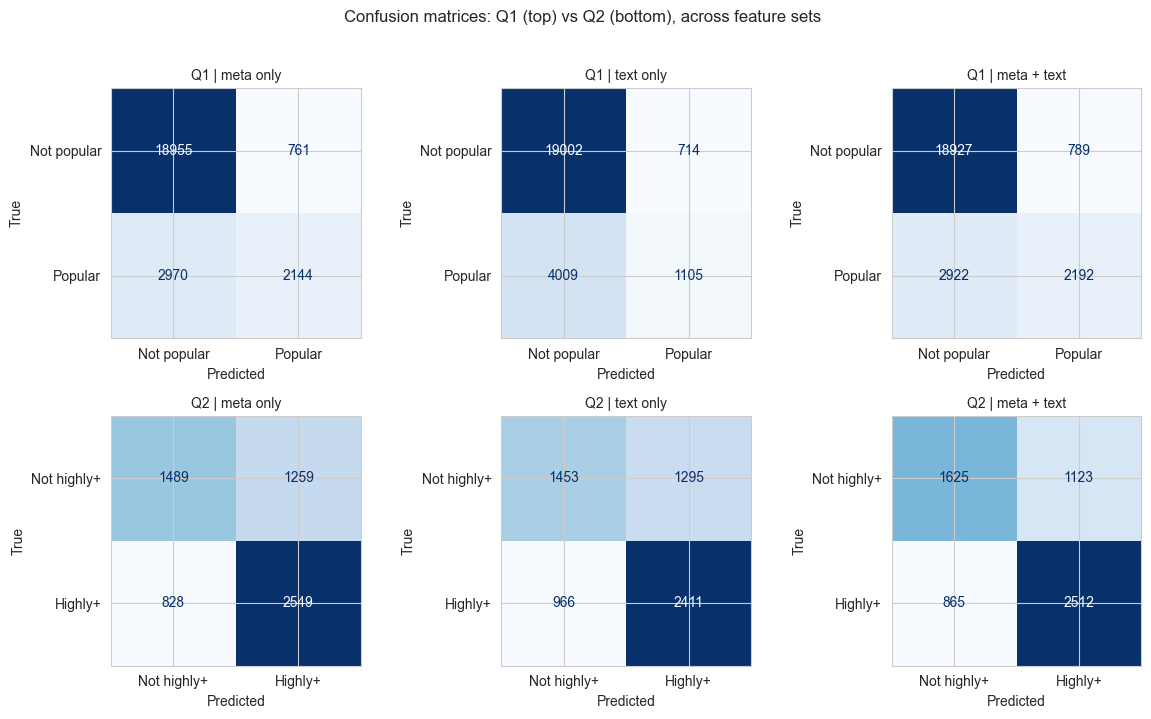

💾 Saved to ..\outputs\figures\06_confusion_matrices.png


In [16]:
# ===== Step 27: Confusion matrices visualisation =====
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

experiments_ordered = [
    ('Q1 | meta only',   ['Not popular', 'Popular']),
    ('Q1 | text only',   ['Not popular', 'Popular']),
    ('Q1 | meta + text', ['Not popular', 'Popular']),
    ('Q2 | meta only',   ['Not highly+', 'Highly+']),
    ('Q2 | text only',   ['Not highly+', 'Highly+']),
    ('Q2 | meta + text', ['Not highly+', 'Highly+']),
]

for ax, (name, labels) in zip(axes.flatten(), experiments_ordered):
    X_test, y_test, y_pred = test_data[name]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion matrices: Q1 (top) vs Q2 (bottom), across feature sets", 
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"💾 Saved to {FIG_DIR / '06_confusion_matrices.png'}")